**Contact**: changseop@google.com

### 개요
*   DataLakehouse의 Table 포맷 표준화가 되어가고 있는 Iceberg 이해
*   BigLake에 대한 이해
*   DataLkaehouse에서 Iceberg 활용한 BigQuery와 Dataproc에 대한 이해  
<br>  

### 목차
1.   BigQuery Managed Iceberg Table(Time Travel)
2.   Catalog(BigLake Managed Iceberg Table)
3.   File Compaction
4.   Dataproc Lightning Engine Performance(Standard vs Premium)


### 0. Set-up Envrionments

해당 실습에 필요한 권한과 필요한 자원을 설정합니다.

In [8]:
import google.auth
import subprocess
import requests
import pyspark
import json
import sys
from pyspark.sql import SparkSession
from google.cloud import bigquery

### Project의 ID 및 account 정보 획득
project_id = google.auth.default()[1]
user_account = !gcloud config get-value account
user_account = user_account[0]

### Service account 정보 획득 및 조합
project_number = !gcloud projects list --filter="projectId:{project_id}" --format="value(projectNumber)"
project_number = project_number[0].strip()
### service_account 용도
### 1. dataproc cluster 생성
service_account = f"{project_number}-compute@developer.gserviceaccount.com"

### 이외 변수 설정
region = "asia-northeast3"
cluster_name = f"iceberg-dataproc-{project_number}"
catalog_name = f"{project_number}_iceberg_catalog"
connection_id = "biglake-iceberg-conn"
step1_bucket_name = f"{project_number}-commercial-bucket"
step2_classic_catalog_name = f"{project_number}_classic_iceberg_catalog"
step2_bqcf_catalog_name = f"{project_number}_standard_iceberg_catalog"

### BigQuery 연결
client = bigquery.Client(project=project_id)

### 검증
print("🏁 다음과 같이 할당 완료되었습니다.")
print(f"✅ project_id : {project_id}")
print(f"✅ project_number : {project_number}")
print(f"✅ user_account : {user_account}")
print(f"✅ service_account : {service_account}")
print(f"✅ region : {region}")
print(f"✅ cluster_name : {cluster_name}")
print(f"✅ catalog_name : {catalog_name}")
print(f"✅ connection_id : {connection_id}")
print(f"✅ step1_bucket_name : {step1_bucket_name}")
print(f"✅ step2_classic_catalog_name : {step2_classic_catalog_name}")
print(f"✅ step2_bqcf_catalog_name : {step2_bqcf_catalog_name}")

🏁 다음과 같이 할당 완료되었습니다.
✅ project_id : icebergnotbookreview
✅ project_number : 497822924350
✅ user_account : admin@changseop.altostrat.com
✅ service_account : 497822924350-compute@developer.gserviceaccount.com
✅ region : asia-northeast3
✅ cluster_name : iceberg-dataproc-497822924350
✅ catalog_name : 497822924350_iceberg_catalog
✅ connection_id : biglake-iceberg-conn
✅ step1_bucket_name : 497822924350-commercial-bucket
✅ step2_classic_catalog_name : 497822924350_classic_iceberg_catalog
✅ step2_bqcf_catalog_name : 497822924350_standard_iceberg_catalog


In [2]:
### IAM 권한부여(BigQuery Admin, BigLake Admin, Storage Admin)
print("✏️ 사용 계정에 권한 부여 시작...")

roles = ["roles/bigquery.admin", "roles/biglake.admin", "roles/storage.admin"]

for role in roles:
    cmd = [
        "gcloud", "projects", "add-iam-policy-binding", project_id,
        "--member", f"user:{user_account}",
        "--role", role
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0:
        print(f"✅: {role}")
    else:
        print(f"⚠️ 에러 로그: {result.stderr.strip()}")
        print(f"❌ 권한 부여 실패: {role}")

### IAM 권한부여(Dataproc Admin)
print("✏️ 서비스 계정에 권한 부여 시작...")

roles = ["roles/dataproc.worker", "roles/bigquery.admin",
         "roles/biglake.admin", "roles/storage.admin",
         "roles/serviceusage.serviceUsageConsumer"]

for role in roles:
    cmd = [
        "gcloud", "projects", "add-iam-policy-binding", project_id,
        "--member", f"serviceAccount:{service_account}",
        "--role", role
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0:
        print(f"✅: {role}")
    else:
        print(f"⚠️ 에러 로그: {result.stderr.strip()}")
        print(f"❌ 권한 부여 실패: {role}")

print("🏁 작업 완료")

✏️ 사용 계정에 권한 부여 시작...
✅: roles/bigquery.admin
✅: roles/biglake.admin
✅: roles/storage.admin
✏️ 서비스 계정에 권한 부여 시작...
✅: roles/dataproc.worker
✅: roles/bigquery.admin
✅: roles/biglake.admin
✅: roles/storage.admin
✅: roles/serviceusage.serviceUsageConsumer
🏁 작업 완료


In [3]:
### 필요한 API 활성화

print("🚀 API 활성화 시작..")

cmd = ["gcloud", "services", "enable", "cloudresourcemanager.googleapis.com"]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
  print("🏁 API 활성화 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ 활성화 실패")

🚀 API 활성화 시작..
🏁 API 활성화 완료


In [10]:
### Dataproc Cluster 생성

print(f"🔧 {cluster_name} 명으로 클러스터 생성 시작...")

cmd = ["gcloud", "dataproc", "clusters", "create", cluster_name,
       "--enable-component-gateway",
       "--project", project_id,
       "--region", region,
       "--optional-components", "ICEBERG",
       "--image-version", "2.3"]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

log_stack = ""
for line in result.stdout:
  print(line, end='')
  log_stack += line

result.wait()

if result.returncode == 0 or "ALREADY_EXISTS" in log_stack:
  print("🏁 Cluster 생성 완료(또는 이미 존재)")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print(f"❌ Cluster 생성 실패")

🔧 iceberg-dataproc-497822924350 명으로 클러스터 생성 시작...
Waiting on operation [projects/icebergnotbookreview/regions/asia-northeast3/operations/95acd8e4-b474-3923-b0f0-19239cad16fe].
Waiting for cluster creation operation...
..............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [11]:
### GCS 생성
### Bucket 명은 해당 실습의 Catalog 명으로 활용되니 고려하여 생성합니다.

print(f"📦 {catalog_name} 명으로 버킷 생성 시작...")

cmd = ["gcloud", "storage", "buckets", "create", f"gs://{catalog_name}", "--location=asia-northeast3"]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0 or "you already own it" in result.stderr :
  print("🏁 Bucket 생성 완료(또는 이미 존재)")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ Bucket 생성 실패")

📦 497822924350_iceberg_catalog 명으로 버킷 생성 시작...
🏁 Bucket 생성 완료(또는 이미 존재)


### 1. BigQuery Managed Iceberg Table(Time Travel)

#### Objective
*   BigLake Iceberg table in BQ를 이해하고 Time travel 테스트 합니다.

#### Preface
현 과정부터 Lightning Engine까지의 실습은 Iceberg에 대한 이해와 BigLake 개요에 대한 전반적인 이해를 전제합니다.
GCP에서는 Iceberg를 활용한 구성으로는 BigLake Iceberg Tables, BigLake Iceberg Table in BQ 방식이 존재합니다. 추후 진행하는 실습에서는 BigLake Iceberg Tables를 활용한다면 여기서는 BigLake Iceberg in BQ(BigQuery Managed Iceberg Table)를 활용해봅니다. 이후, Time travel 검증을 통해 과거 데이터가 필요한 경우를 대응할 수 있음을 확인합니다.


In [12]:
###Step1. Dummy data 생성(약 10GB)
###Cross Join을 활용해 1만개 x 1만개 함으로써 1억개 row 생성
###해당 쿼리는 약 2~3분의 시간소요가 됩니다.

query = f"""
CREATE SCHEMA IF NOT EXISTS `{project_id}.test_schema_kr`
OPTIONS(
  location = '{region}'
);

CREATE OR REPLACE TABLE `{project_id}.test_schema_kr.dummy_orders`
PARTITION BY DATE(order_at) -- 날짜별 파티셔닝
AS
WITH generator AS (
  SELECT
    x, y
  FROM UNNEST(GENERATE_ARRAY(1, 10000)) AS x,
       UNNEST(GENERATE_ARRAY(1, 10000)) AS y
)
SELECT
  -- UUID 생성 (고유 주문번호)
  GENERATE_UUID() AS order_id,

  -- 사용자 ID (1 ~ 100만 명 중 랜덤)
  CAST(FLOOR(RAND() * 1000000) + 1 AS INT64) AS user_id,

  -- 상품 ID (A-00001 ~ A-00100 중 랜덤)
  CONCAT('P-', CAST(FLOOR(RAND() * 10000) + 1 AS STRING)) AS product_id,

  -- 주문 금액 (1,000원 ~ 100,000원)
  CAST(FLOOR(RAND() * 100000) + 1000 AS INT64) AS amount,

  -- 주문 상태 (랜덤 배정)
  CASE CAST(FLOOR(RAND() * 5) AS INT64)
    WHEN 0 THEN 'ORDERED'
    WHEN 1 THEN 'PAID'
    WHEN 2 THEN 'SHIPPED'
    WHEN 3 THEN 'DELIVERED'
    WHEN 4 THEN 'CANCELLED'
  END AS status,

  -- 주문 시간 (최근 30일 이내 랜덤 시간)
  TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL CAST(FLOOR(RAND() * 30 * 24 * 60 * 60) AS INT64) SECOND) AS order_at

FROM generator;
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 데이터세트, 테이블 그리고 더미 데이터 생성 완료")


🏁 데이터세트, 테이블 그리고 더미 데이터 생성 완료


In [13]:
###Step2. 새 Bucket 생성(환경세팅 단계에서의 Bucket과 별개) 후 해당 Bucket으로 위에서 생성한 데이터를 Export
###이때, 단일 파일 1GB Limit이 있어 하기 코드로 파일 분할해 Export 진행

print(f"📦 {step1_bucket_name} 명으로 버킷 생성 시작...")

cmd = ["gcloud", "storage", "buckets", "create", f"gs://{step1_bucket_name}", "--location=asia-northeast3"]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
  print("🏁 Bucket 생성 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ Bucket 생성 실패")

📦 497822924350-commercial-bucket 명으로 버킷 생성 시작...
🏁 Bucket 생성 완료


In [14]:
### Step2의 Export 단계
query = f"""
EXPORT DATA OPTIONS(
  uri='gs://{step1_bucket_name}/commercial_data/orders/orders_*.parquet',
  format='PARQUET',
  compression='ZSTD',
  overwrite=true
) AS
SELECT * FROM `{project_id}.test_schema_kr.dummy_orders`;
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 Bucket에 Export 완료했습니다. Bucket에서 실제로 확인 해보세요.")

🏁 Bucket에 Export 완료했습니다. Bucket에서 실제로 확인 해보세요.


In [15]:
###Step3. BigQuery Connection 생성
###BigLake 지원 Connector 생성하는 단계로 데이터세트, 테이블 그리고 리전이 동일해야 합니다.

print(f"🏃 BigLake 지원 Connector를 {connection_id} 명으로 생성 시작...")

conn_create_cmd = [
    "bq", "mk", "--connection",
    "--location", region,
    "--project_id", project_id,
    "--connection_type","CLOUD_RESOURCE",
    connection_id
]

result = subprocess.run(conn_create_cmd, capture_output=True, text=True)

if result.returncode == 0 or "already exists" in result.stderr:
    print(f"✅ 커넥션 생성 완료 (또는 이미 존재)")
else:
    print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
    print(f"❌ 커넥션 생성 실패했습니다.")

print("🏁 작업 완료")

🏃 BigLake 지원 Connector를 biglake-iceberg-conn 명으로 생성 시작...
✅ 커넥션 생성 완료 (또는 이미 존재)
🏁 작업 완료


In [16]:
###Step3의 Connection에 필요한 권한 부여
print(f"🏃 Connection의 Service Account ID 추출...")

describe_conn_cmd = [
    "bq", "show", "--connection",
    "--format","json",
    f"{project_id}.{region}.{connection_id}",
]

desc_result = subprocess.run(describe_conn_cmd, capture_output=True, text=True)

if desc_result.returncode == 0:
    conn_info = json.loads(desc_result.stdout)
    conn_service_account = conn_info['cloudResource']['serviceAccountId']
    print(f"✅ 연결 서비스 계정: {conn_service_account}")
else:
    print("❌ 서비스 계정 정보 로드 실패했습니다.")


print(f"🏃 서비스 계정에 권한 부여 시작...")

roles = ["roles/biglake.admin", "roles/storage.admin"]

for role in roles:
    cmd = [
        "gcloud", "projects", "add-iam-policy-binding", project_id,
        "--member", f"serviceAccount:{conn_service_account}",
        "--role", role
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0:
        print(f"✅: {role}")
    else:
        print(f"⚠️ 에러 로그: {result.stderr.strip()}")
        print(f"❌ 권한 부여 실패: {role}")

print("🏁 작업 완료")

🏃 Connection의 Service Account ID 추출...
✅ 연결 서비스 계정: bqcx-497822924350-axa5@gcp-sa-bigquery-condel.iam.gserviceaccount.com
🏃 서비스 계정에 권한 부여 시작...
✅: roles/biglake.admin
✅: roles/storage.admin
🏁 작업 완료


In [17]:
###Step4. External Table 생성

query = f"""
CREATE OR REPLACE EXTERNAL TABLE `test_schema_kr.temp_raw_reader`
WITH CONNECTION `{project_id}.{region}.{connection_id}`
OPTIONS (
format = 'PARQUET',
uris = ['gs://{step1_bucket_name}/commercial_data/orders/orders_*.parquet']  );
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 External Table 생성 완료")

🏁 External Table 생성 완료


In [18]:
###Step5. Iceberg Table 생성

query = f"""
CREATE OR REPLACE TABLE `test_schema_kr.iceberg_orders`
WITH CONNECTION `{project_id}.{region}.{connection_id}`
OPTIONS (

  table_format = 'ICEBERG',
  file_format = 'PARQUET',
  storage_uri = 'gs://{step1_bucket_name}/iceberg_commerical_data/orders'

) AS
SELECT * FROM `test_schema_kr.temp_raw_reader`;
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 Iceberg Table 생성 완료")

🏁 Iceberg Table 생성 완료


In [36]:
###Step6. Time Travel 확인
### 해당 예제는 위에서 생성한 시점으로 10분이 지나야합니다. 10분의 커피타임을 즐겨보시거나 아리 past 쉘에서 1분으로 수정 후 해보세요.
###하나의 ORDERED인 id를 1개 추출 후 CANCELED로 변환합니다.
###이후, Time travel을 통해 과거엔 ORDERED임을 확인합니다.

query = """
SELECT order_id, status, order_at
FROM `test_schema_kr.iceberg_orders`
WHERE status = 'ORDERED'
LIMIT 1;
"""

query_job = client.query(query, location=region)
results = list(query_job.result())
res = results[0].order_id
print(f"✅ 추출된 order_id: {res}")
print("🏁 추출 완료")

✅ 추출된 order_id: e3b50ed0-e9ab-4774-bac2-0f917971861c
🏁 추출 완료


In [37]:
### 찾은 1개의 order_id를 아래에 적용해 진행합니다.
### 업데이트 진행

query = f"""
UPDATE `test_schema_kr.iceberg_orders`
SET status = 'CANCELLED'
WHERE order_id = '{res}';
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 업데이트 완료")

🏁 업데이트 완료


In [38]:
### Time travel 비교
### Current

query = f"""
SELECT order_id, status, 'Current' as version
FROM `test_schema_kr.iceberg_orders`
WHERE order_id = '{res}'
"""

query_job = client.query(query, location=region)
print(query_job.to_dataframe())

                               order_id     status  version
0  e3b50ed0-e9ab-4774-bac2-0f917971861c  CANCELLED  Current


In [39]:
### Past

query = f"""
SELECT order_id, status, 'Past' as version
FROM `test_schema_kr.iceberg_orders`
  FOR SYSTEM_TIME AS OF TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 10 MINUTE)
WHERE order_id = '{res}';
"""

query_job = client.query(query, location=region)
print(query_job.to_dataframe())

                               order_id   status version
0  e3b50ed0-e9ab-4774-bac2-0f917971861c  ORDERED    Past


### 2. Catalog

#### Objective
*   Legacy인 BigLake metastore (Classic) + Custom Iceberg catalog 를 사용해봅니다.
*   Iceberg REST catalog 이해합니다.
*   BigQuery catalog Federation 이해합니다.


#### Preface
본 과정은 Google이 Iceberg의 metadata를 어떻게 관리하고 확장해오고 있는지 단계별로 알 수 있는 과정입니다. 과거에는 BigLake metastore (Classic) (주의할 점은 여전히 BigLake metastore라는 이름이 쓰이지만 과거에 쓰인 BigLake metastore는 Classic이므로 다릅니다. 즉, BigLake metastore (Classic)은 Legacy라 볼 수 있습니다.) 을 사용했으나 현재는 Iceberg의 표준인 Iceberg REST catalog를 활용하고 있습니다. 이를, BigLake metastore가 지원하고 있으며 Spark, Flink 등 다른 OSS 들이 같은 metadata를 바라 볼 수 있도록 하고 있습니다.
더 나아가, BigQuery catalog Federation는 BigQuery를 활용하면서도 Iceberg REST catalog이 가진 장점인 ‘Interoperability’와 ‘standard’를 보장하고 있습니다.
지금부터는 이 3가지를 다뤄보며 익숙해지고 여러분들이 실무에 적용할 전략을 고민할 수 있는 시간을 가져보겠습니다.

In [25]:
###BigLake API 활성화

print("🚀 API 활성화 시작..")

cmd = ["gcloud", "services", "enable", "biglake.googleapis.com"]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
  print("🏁 API 활성화 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ 활성화 실패")

🚀 API 활성화 시작..
🏁 API 활성화 완료


처음은 [BigLake metastore(Classic)](https://docs.cloud.google.com/bigquery/docs/manage-open-source-metadata#how-metastore-works)을 다뤄보겠습니다.

In [26]:
###Step1. BigLake metastore(Classic) + Custom Iceberg Catalog
###Classic으로 생성된 Catalog는 BigLake 콘솔에서 확인이 안됩니다.

token = subprocess.check_output(["gcloud", "auth", "print-access-token"], text=True).strip()
url = f"https://biglake.googleapis.com/v1/projects/{project_id}/locations/{region}/catalogs"
headers = {
    "Authorization": f"Bearer {token}",
    "Accept": "application/json",
    "Content-Type": "application/json"
}
params = {"catalogId": step2_classic_catalog_name}
data = {}

print(f"🏷️ Catalog 생성 요청 중: {step2_classic_catalog_name}...")
response = requests.post(url, headers=headers, params=params, json=data)

if response.status_code == 200:
    print("✅ Catalog 생성 완료!")
    print(json.dumps(response.json(), indent=2))
elif response.status_code == 409:
    print("⚠️ 이미 존재하는 Catalog입니다.")
else:
    print(f"❌ 생성 실패 (Status Code: {response.status_code})")
    print(response.text)

print("🏁 작업 완료")

🏷️ Catalog 생성 요청 중: 497822924350_classic_iceberg_catalog...
✅ Catalog 생성 완료!
{
  "name": "projects/497822924350/locations/asia-northeast3/catalogs/497822924350_classic_iceberg_catalog",
  "createTime": "2026-03-11T02:56:48.606226Z",
  "updateTime": "2026-03-11T02:56:48.606226Z"
}
🏁 작업 완료


In [27]:
###job 파일을 위한 변수 설정
CATALOG_NAME_IN_SPARK = "spark_iceberg_catalog"
WAREHOUSE_PATH = f"gs://{catalog_name}/custom_warehouse"

In [28]:
job_code=f"""
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \\
    .appName('Iceberg-Custom-Catalog-Test') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .getOrCreate()

try:
    print("🏃 Catalog 적용...")
    spark.sql("USE {CATALOG_NAME_IN_SPARK}")

    print("🏃 Namespace(Dataset) 생성...")
    spark.sql("CREATE NAMESPACE IF NOT EXISTS changseop_custom_db")
    spark.sql("USE changseop_custom_db")

    print("🏃 Table 생성...")
    spark.sql('''
        CREATE TABLE IF NOT EXISTS custom_catalog_test_table (
            id BIGINT,
            msg STRING
        ) USING ICEBERG
    ''')

    print("🏃 INSERT 적용...")
    spark.sql('''
        INSERT INTO custom_catalog_test_table VALUES
        (1, '설정을'),
        (2, '완벽하게 따라했습니다'),
        (3, 'Jar 파일 필수!')
    ''')

    print('🏁 결과 조회:')
    spark.sql('SELECT * FROM custom_catalog_test_table').show()

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
"""

with open("classic_blms_job_001.py", "w") as f:
    f.write(job_code)

print("✅ classic_blms_job_001.py 생성 완료")

✅ classic_blms_job_001.py 생성 완료


In [29]:
###Step1.2. Job 제출
###Custom Iceberg Catalog는 Iceberg REST 표준을 쓰지 않고 Google이 제작한 BigLake 전용 코드를 사용합니다.
###즉, jar 파일이 필요합니다. (Internet과 통신되는 환경일 것)

print(f"✍️ Job 제출...")

properties = [
    f"spark.sql.catalog.{CATALOG_NAME_IN_SPARK}=org.apache.iceberg.spark.SparkCatalog",
    f"spark.sql.catalog.{CATALOG_NAME_IN_SPARK}.catalog-impl=org.apache.iceberg.gcp.biglake.BigLakeCatalog",
    f"spark.sql.catalog.{CATALOG_NAME_IN_SPARK}.gcp_project={project_id}",
    f"spark.sql.catalog.{CATALOG_NAME_IN_SPARK}.gcp_location={region}",
    f"spark.sql.catalog.{CATALOG_NAME_IN_SPARK}.blms_catalog={step2_classic_catalog_name}",
    f"spark.sql.catalog.{CATALOG_NAME_IN_SPARK}.warehouse=gs://{catalog_name}/custom_warehouse",
    "spark.jars.packages=org.apache.iceberg:iceberg-spark-runtime-3.3_2.12:1.4.2"
]

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "classic_blms_job_001.py",
       "--cluster", cluster_name,
       "--region", region,
       "--jars", "gs://spark-lib/biglake/biglake-catalog-iceberg1.9.1-0.1.3-with-dependencies.jar",
       "--properties",",".join(properties)]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print(f"❌ Job 동작 실패")

✍️ Job 제출...
Job [d8a8000da40a48abbf51d04bf08df7b6] submitted.
Waiting for job output...
:: loading settings :: url = jar:file:/usr/lib/spark/jars/ivy-2.5.2.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.3_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-181621fc-6b0f-4b51-bf50-629604293f21;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.3_2.12;1.4.2 in central
downloading https://repo1.maven.org/maven2/org/apache/iceberg/iceberg-spark-runtime-3.3_2.12/1.4.2/iceberg-spark-runtime-3.3_2.12-1.4.2.jar ...
	[SUCCESSFUL ] org.apache.iceberg#iceberg-spark-runtime-3.3_2.12;1.4.2!iceberg-spark-runtime-3.3_2.12.jar (149ms)
:: resolution report :: resolve 400ms :: artifacts dl 152ms
	:: modules in use:
	org.apache.iceberg#iceberg-spark-runtime-3.3_2.12;1.4.2 from central in [default]
	--

In [30]:
###Step1.3. BigQuery External Table 생성 및 blms 검증
###메타데이터는 blms를 통해 자동 동기화되는 방식으로 BigLake Metastore(Classic)에서만 가능

query = f"""
CREATE SCHEMA IF NOT EXISTS `{project_id}.classic_blms`
OPTIONS(
  location = '{region}'
);

CREATE OR REPLACE EXTERNAL TABLE `classic_blms.blms_test_00`
WITH CONNECTION `{project_id}.{region}.{connection_id}`
OPTIONS (
  FORMAT = 'ICEBERG',
  uris = ['blms://projects/{project_id}/locations/{region}/catalogs/{step2_classic_catalog_name}/databases/changseop_custom_db/tables/custom_catalog_test_table']
);
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 테이블 생성 완료")

🏁 테이블 생성 완료


👀 Let's CHECK!  

classic_blms > blms_test_00 > Details > Source URI(s) 에서 blms://projects/YOUR_PROJECT/locations/YOUR_REGION/catalogs/YOUR_CATALOG_NAME/databases/changseop_custom_db/tables/custom_catalog_test_table 와 같이 되어있는지 그리고, Source format이 ICEBERG인지 확인합니다.

In [31]:
###Step1.4. Metadata가 동기화되는지 확인
###Metadata가 동기화가 된다는 뜻은 data 변화를 감지하고 반영한다 의미입니다.

job_code=f"""
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \\
    .appName('Iceberg-Custom-Catalog-Test') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .getOrCreate()

try:
    print('🏃 Catalog {CATALOG_NAME_IN_SPARK} 사용...')
    spark.sql('USE {CATALOG_NAME_IN_SPARK}')

    print('🏃 Namespace(Dataset) 사용...')
    spark.sql('USE changseop_custom_db')

    print('🏃 데이터 INSERT 적용...')
    spark.sql('''
        INSERT INTO custom_catalog_test_table VALUES
        (4, '메타데이터'),
        (5, '동기화'),
        (6, '확인합니다.')
    ''')

    print('🏃 결과 조회:')
    spark.sql('SELECT * FROM custom_catalog_test_table').show()

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
"""

with open("classic_blms_job_002.py", "w") as f:
    f.write(job_code)

print("✅ classic_blms_job_002.py 생성 완료")

✅ classic_blms_job_002.py 생성 완료


In [32]:
###변화를 확인하기 위한 Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "classic_blms_job_002.py",
       "--cluster", cluster_name,
       "--region", region,
       "--jars", "gs://spark-lib/biglake/biglake-catalog-iceberg1.9.1-0.1.3-with-dependencies.jar",
       "--properties",",".join(properties)]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print(f"❌ Job 동작 실패")

✍️ Job 제출...
Job [8966f18ba7134a91bad059398e03f160] submitted.
Waiting for job output...
:: loading settings :: url = jar:file:/usr/lib/spark/jars/ivy-2.5.2.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.3_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-cafdb8ad-fff7-4bc3-9ff5-2597f87886c6;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.3_2.12;1.4.2 in central
:: resolution report :: resolve 129ms :: artifacts dl 3ms
	:: modules in use:
	org.apache.iceberg#iceberg-spark-runtime-3.3_2.12;1.4.2 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	-------------------------------------------------

In [34]:
###결과확인
query = f"""
SELECT *
FROM `classic_blms.blms_test_00`
ORDER BY 1
"""

query_job = client.query(query, location=region)
print(query_job.to_dataframe())

   id          msg
0   1          설정을
1   2  완벽하게 따라했습니다
2   3   Jar 파일 필수!
3   4        메타데이터
4   5          동기화
5   6       확인합니다.


다음은 [Iceberg REST catalog](https://docs.cloud.google.com/biglake/docs/blms-rest-catalog#process)를 진행해보겠습니다.

In [40]:
###Step2. BigLake Catalog 생성합니다.

print(f"🏷️ {catalog_name} 명으로 카탈로그 생성 시작...")

cmd = ["gcloud", "alpha", "biglake", "iceberg",
       "catalogs", "create", catalog_name,
       "--catalog-type=gcs-bucket"]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
  print("🏁 카탈로그 생성 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ 카탈로그 생성 실패")


🏷️ 497822924350_iceberg_catalog 명으로 카탈로그 생성 시작...
🏁 카탈로그 생성 완료


In [41]:
###해당 단계의 필요환 환경변수 지정
namespace_name = "blms_rest_db"
table_name = "blms_rest_test_00"

In [42]:
###Step2.1. DDL 테스트 파일 작성
job_code=f"""
import pyspark
from pyspark.context import SparkContext
from pyspark.sql import SparkSession

spark = SparkSession.builder \\
        .appName('Iceberg-Changseop-test') \\
        .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
        .getOrCreate()


try:
    print('🏃 Catalog 지정...')
    spark.sql('USE {catalog_name}')
    print('🏃 Namespace 확인합니다. 만약, 없다면 생성합니다...')
    spark.sql('CREATE NAMESPACE IF NOT EXISTS {namespace_name}')
    spark.sql('USE {namespace_name}')
    spark.sql('SHOW NAMESPACES').show()

    #DDL
    print('🏃 Table 생성...')
    spark.sql('CREATE TABLE IF NOT EXISTS {table_name} (id int, data string) USING ICEBERG;')

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
"""

with open("blms_rest_00.py", "w") as f:
    f.write(job_code)

print("✅ blms_rest_00.py 생성 완료")

✅ blms_rest_00.py 생성 완료


In [43]:
###Step2.2. Job 제출

print(f"✍️ Job 제출...")

properties = [
    f"spark.sql.catalog.{catalog_name}=org.apache.iceberg.spark.SparkCatalog",
    f"spark.sql.catalog.{catalog_name}.type=rest",
    f"spark.sql.catalog.{catalog_name}.uri=https://biglake.googleapis.com/iceberg/v1/restcatalog",
    f"spark.sql.catalog.{catalog_name}.warehouse=gs://{catalog_name}",
    f"spark.sql.defaultCatalog={catalog_name}",
    f"spark.sql.catalog.{catalog_name}.header.x-goog-user-project={project_id}",
    f"spark.sql.catalog.{catalog_name}.rest.auth.type=org.apache.iceberg.gcp.auth.GoogleAuthManager",
    f"spark.sql.catalog.{catalog_name}.io-impl=org.apache.iceberg.gcp.gcs.GCSFileIO",
    f"spark.sql.catalog.{catalog_name}.rest-metrics-reporting-enabled=false"
]

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "blms_rest_00.py",
       "--cluster", cluster_name,
       "--region", region,
       "--properties",",".join(properties)]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Job [7e1aff768a8d434b8f3c8b27de79b545] submitted.
Waiting for job output...
26/03/11 03:14:16 INFO SparkEnv: Registering MapOutputTracker
26/03/11 03:14:16 INFO SparkEnv: Registering BlockManagerMaster
26/03/11 03:14:16 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/11 03:14:16 INFO SparkEnv: Registering OutputCommitCoordinator
26/03/11 03:14:17 INFO MetricsConfig: Loaded properties from hadoop-metrics2.properties
26/03/11 03:14:17 INFO MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
26/03/11 03:14:17 INFO MetricsSystemImpl: google-hadoop-file-system metrics system started
26/03/11 03:14:18 INFO DataprocSparkPlugin: Registered 189 driver metrics
26/03/11 03:14:18 INFO DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at iceberg-dataproc-497822924350-m.asia-northeast3-b.c.icebergnotbookreview.internal./10.178.0.9:8032
26/03/11 03:14:18 INFO AHSProxy: Connecting to Application History server at iceberg-dataproc-497822924350-

👀 Let's CHECK!  

GCS에 반영되었는지 확인합니다.

In [44]:
###Step2.3. DML 테스트 파일 작성
job_code=f"""
import pyspark
from pyspark.context import SparkContext
from pyspark.sql import SparkSession

spark = SparkSession.builder \\
        .appName('Iceberg-Changseop-test') \\
        .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
        .getOrCreate()

try:
    print('🏃 Catalog 지정...')
    spark.sql('USE {catalog_name}')
    print('🏃 Namespace 확인합니다. 만약, 없다면 생성합니다...')
    spark.sql('CREATE NAMESPACE IF NOT EXISTS {namespace_name}')
    spark.sql('USE {namespace_name}')
    spark.sql('SHOW NAMESPACES').show()

    #DML
    print('🏃 데이터 삽입...')
    spark.sql('''INSERT INTO {table_name} VALUES
                (1000, '천방지축 어리둥절'),
                (1001, '빙글빙글 돌아가는'),
                (1002, '창섭의 하루'),
                (1003, '우리의 창섭은 정말 못말려'),
                (1004, '창섭아~~~~');''')

    #DML2
    print('🏃 데이터 쿼리...')
    df = spark.sql('SELECT * FROM {table_name};')
    df.show()


except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
"""

with open("blms_rest_01.py", "w") as f:
    f.write(job_code)

print("✅ blms_rest_01.py 생성 완료")

✅ blms_rest_01.py 생성 완료


In [45]:
###Step2.4. Job 제출

print(f"✍️ Job 제출...")

properties = [
    f"spark.sql.catalog.{catalog_name}=org.apache.iceberg.spark.SparkCatalog",
    f"spark.sql.catalog.{catalog_name}.type=rest",
    f"spark.sql.catalog.{catalog_name}.uri=https://biglake.googleapis.com/iceberg/v1/restcatalog",
    f"spark.sql.catalog.{catalog_name}.warehouse=gs://{catalog_name}",
    f"spark.sql.defaultCatalog={catalog_name}",
    f"spark.sql.catalog.{catalog_name}.header.x-goog-user-project={project_id}",
    f"spark.sql.catalog.{catalog_name}.rest.auth.type=org.apache.iceberg.gcp.auth.GoogleAuthManager",
    f"spark.sql.catalog.{catalog_name}.io-impl=org.apache.iceberg.gcp.gcs.GCSFileIO",
    f"spark.sql.catalog.{catalog_name}.rest-metrics-reporting-enabled=false"
]

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "blms_rest_01.py",
       "--cluster", cluster_name,
       "--region", region,
       "--properties",",".join(properties)]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Job [30fd3d16dad04d17bf56012a555050dc] submitted.
Waiting for job output...
26/03/11 03:15:28 INFO SparkEnv: Registering MapOutputTracker
26/03/11 03:15:28 INFO SparkEnv: Registering BlockManagerMaster
26/03/11 03:15:28 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/11 03:15:28 INFO SparkEnv: Registering OutputCommitCoordinator
26/03/11 03:15:29 INFO MetricsConfig: Loaded properties from hadoop-metrics2.properties
26/03/11 03:15:29 INFO MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
26/03/11 03:15:29 INFO MetricsSystemImpl: google-hadoop-file-system metrics system started
26/03/11 03:15:30 INFO DataprocSparkPlugin: Registered 189 driver metrics
26/03/11 03:15:30 INFO DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at iceberg-dataproc-497822924350-m.asia-northeast3-b.c.icebergnotbookreview.internal./10.178.0.9:8032
26/03/11 03:15:30 INFO AHSProxy: Connecting to Application History server at iceberg-dataproc-497822924350-

GCS에서 data와 metadata에 따라 저장됨을 확인합니다.  

👀 Metadata에서 알아둘 점

*   json 형식의 파일에는 모든 history가 담겨있습니다. 예로, 테이블의 column 정보와 버전 별로 스냅샷 파일은 어떤 파일인지 알려줍니다.
이때 어느 json을 보느냐에 맞춰서 time travel이 가능합니다.
*   snapshot 은 특정 시점의 테이블 상태를 정의하는 파일로 Iceberg 구조에서 Manifest List입니다.
*   avro 형태의 파일은 Manifest file입니다. 해당 파일이 실제 데이터 파일들의 정보와 통계 정보가 담겨져있습니다. 때문에, 이 파일을 통해서 모든 데이터 파일을 읽을 필요 없이 필요한 파일만 읽게 됩니다. 이를, Pruning이라고 합니다.



In [46]:
###Step2.4. BQ에서 External table 생성
###!!!uris는 직접 수정하세요!!!
###uris의 주소는 Buckets > 해당 실습의 버킷 > blms_rest_db > blms_rest_test_00 > metadata 로 진입합니다.
###그 다음, 00001-69aa882c-0000-2cae-b1a1-24058878f7f0.metadata.json 형식의 파일에서 가장 높은 번호인 파일로 진입합니다.
###그 파일에서 나타나는 Overview에서 gsutil URI를 복사한 후 붙여넣습니다.


query = f"""
CREATE SCHEMA IF NOT EXISTS `standard_blms`;

CREATE OR REPLACE EXTERNAL TABLE `standard_blms.blms_test_00`
OPTIONS (
  format = 'ICEBERG',
  uris = ['gs://993674588339_iceberg_catalog/blms_rest_db/blms_rest_test_00/metadata/00001-69aa882c-0000-2cae-b1a1-24058878f7f0.metadata.json']
);
"""

query_job = client.query(query, location=region)
query_job.result()
print("🏁 External 테이블 생성 완료")

🏁 External 테이블 생성 완료


👀 Let's CHECK!  

standard_blms > blms_rest_00 > Details > Source URI(s) 에서 gs://YOUR_BUCKET/blms_rest_db/blms_rest_test_00/metadata/00001-69aa882c-0000-2cae-b1a1-24058878f7f0.metadata.json와 같이 지정된 주소로 되어있는지 그리고, Source format이 ICEBERG인지 확인합니다.

In [47]:
###Step2.5. BQ에서 쿼리(Interoperability 검증)

query = f"""
SELECT *
FROM `standard_blms.blms_test_00`
ORDER BY 1
"""

query_job = client.query(query, location=region)
print(query_job.to_dataframe())

     id            data
0  1000       천방지축 어리둥절
1  1001       빙글빙글 돌아가는
2  1002          창섭의 하루
3  1003  우리의 창섭은 정말 못말려
4  1004         창섭아~~~~


⚠️ 참고하세요!  

*   위 방식은 변화가 일어난 경우 Bigquery에서는 알 수가 없습니다. 때문에, metadata를 직접 갱신해야하기 때문에 위에서 External table이 바라보는 uris를 변경하여 최신 metadata를 참조할 수 있도록 변경해야 합니다. (반자동)
*   주의할 점은 Data가 BigQuery에 복제되는 것이 아닙니다. GCS에 있는걸 읽는 방식입니다.

다음은 BigQuery Catalog Federation을 해보겠습니다.

In [48]:
###Step3.1. Bucket 생성합니다.

print(f"📦 {step2_bqcf_catalog_name} 명으로 버킷 생성 시작...")

cmd = ["gcloud", "storage", "buckets", "create", f"gs://{step2_bqcf_catalog_name}", "--location", region]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0 or "you already own it" in result.stderr :
  print("🏁 Bucket 생성 완료(또는 이미 존재)")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ Bucket 생성 실패")

📦 497822924350_standard_iceberg_catalog 명으로 버킷 생성 시작...
🏁 Bucket 생성 완료(또는 이미 존재)


In [49]:
###Step3.2. 해당 단계를 위한 Catalog 생성합니다.

print(f"🏷️ {step2_bqcf_catalog_name} 명으로 카탈로그 생성 시작...")

cmd = ["gcloud", "alpha", "biglake", "iceberg",
       "catalogs", "create", step2_bqcf_catalog_name,
       "--catalog-type=gcs-bucket"]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
  print("🏁 카탈로그 생성 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.stderr.strip()}")
  print(f"❌ 카탈로그 생성 실패")

🏷️ 497822924350_standard_iceberg_catalog 명으로 카탈로그 생성 시작...
🏁 카탈로그 생성 완료


In [51]:
###Step3.3. DML 파일 작성
###파라미터화하면 Malfomed request로 받아들이는 문제가 있어 생성하는 과정에서 여러분의 카탈로그 명으로 직접 바꿔야 합니다.
###표시된 곳(# Here!!)을 확인하고 바꿔주세요.
###properties에서 warehouse의 주소를 살펴보세요. 위와 다른점이 무엇인지 탐구해보세요!
###bq:// 의미는 BigQuery에서 metadata를 관리하겠다는 의미가 있습니다.

job_code=f'''
import pyspark
from pyspark.context import SparkContext
from pyspark.sql import SparkSession

#Here!! warehouse 값은 bq://projects/여러분의 project id/locations/사용하는 리전
#Here!! header.x-goog-user-project 값은 여러분의 project id로 반영하세요.
#Here!! spark.sql.defaultCatalog 값을 해당 스텝에서 생성한 카탈로그명으로 변경하세요

spark = SparkSession.builder.appName("Iceberg-Changseop-test") \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.type', 'rest') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.warehouse', 'bq://projects/icebergnotbookreview/locations/asia-northeast3') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.header.x-goog-user-project', 'icebergnotbookreview') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest-metrics-reporting-enabled', 'false') \\
        .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
        .config('spark.sql.defaultCatalog', '497822924350_standard_iceberg_catalog') \\
        .getOrCreate()

try:
    print("🏃 Catalog 지정...")
    spark.sql("USE `497822924350_standard_iceberg_catalog`") #Here!! 카탈로그명
    print("🏃 Namespace 확인합니다. 만약, 없다면 생성합니다...")


    spark.sql("""
        CREATE NAMESPACE IF NOT EXISTS `bqcf_db`
        LOCATION 'gs://497822924350_standard_iceberg_catalog/bqcf_db'
    """) # Here!! 형식은 gs://카탈로그명/네임스페이스명
    spark.sql("USE `bqcf_db`")

    spark.sql("CREATE TABLE bqcf_table (id int, data string) USING ICEBERG;")

    #DML
    print("🏃 데이터 삽입...")
    spark.sql("""INSERT INTO bqcf_table VALUES
                (1000, 'BigQuery'),
                (1001, 'Federation'),
                (1002, '활용해서 만들었어요.');""")

    #DML2
    print("🏃 데이터 쿼리...")
    df = spark.sql("""SELECT * FROM bqcf_table;""")
    df.show()

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''
with open("blms_rest_02.py", "w") as f:
    f.write(job_code)

print("✅ blms_rest_02.py 생성 완료")

✅ blms_rest_02.py 생성 완료


In [52]:
###Step3.4. Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "blms_rest_02.py",
       "--cluster", cluster_name,
       "--region", region]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Job [ab58f769418245dd895430afaf0f7c54] submitted.
Waiting for job output...
26/03/11 03:18:25 INFO SparkEnv: Registering MapOutputTracker
26/03/11 03:18:25 INFO SparkEnv: Registering BlockManagerMaster
26/03/11 03:18:25 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/11 03:18:25 INFO SparkEnv: Registering OutputCommitCoordinator
26/03/11 03:18:26 INFO MetricsConfig: Loaded properties from hadoop-metrics2.properties
26/03/11 03:18:26 INFO MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
26/03/11 03:18:26 INFO MetricsSystemImpl: google-hadoop-file-system metrics system started
26/03/11 03:18:27 INFO DataprocSparkPlugin: Registered 189 driver metrics
26/03/11 03:18:27 INFO DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at iceberg-dataproc-497822924350-m.asia-northeast3-b.c.icebergnotbookreview.internal./10.178.0.9:8032
26/03/11 03:18:27 INFO AHSProxy: Connecting to Application History server at iceberg-dataproc-497822924350-

👀 GCS에서 data와 metadata가 저장됨을 확인하고 BigQuery에서도 생성됨을 확인합니다.  

*   중요한 점은 이중으로 데이터가 있는 것이 아닌 GCS를 참조하는 점이라는 것입니다. 여기서 참조하고 있는 json 파일의 번호가 이후 진행하는 과정을 거치자마자 업데이트가 되는지 확인하는 것이 목표입니다.(앞의 실습은 직접 갱신이 필요한 점과 다른 점이 차별점)  
*   bqcf_db > bqcf_table > Details > Parameters에서 json의 번호를 살펴봅니다.



In [53]:
###Step3.5. 자동갱신 확인을 위한 DML 작업
###파라미터화하면 Malfomed request로 받아들이는 문제가 있어 생성하는 과정에서 여러분의 카탈로그 명으로 직접 바꿔야 합니다.
###표시된 곳(# Here!!)을 확인하고 바꿔주세요.

job_code=f'''
import pyspark
from pyspark.context import SparkContext
from pyspark.sql import SparkSession

#Here!! warehouse 값은 bq://projects/여러분의 project id/locations/사용하는 리전
#Here!! header.x-goog-user-project 값은 여러분의 project id로 반영하세요.
#Here!! spark.sql.defaultCatalog 값을 해당 스텝에서 생성한 카탈로그명으로 변경하세요.

spark = SparkSession.builder.appName("Iceberg-Changseop-test") \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.type', 'rest') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.warehouse', 'bq://projects/icebergnotbookreview/locations/asia-northeast3') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.header.x-goog-user-project', 'icebergnotbookreview') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
        .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest-metrics-reporting-enabled', 'false') \\
        .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
        .config('spark.sql.defaultCatalog', '497822924350_standard_iceberg_catalog') \\
        .getOrCreate()

try:
    print("🏃 Catalog 지정...")
    spark.sql("USE `497822924350_standard_iceberg_catalog`") #Here!! 카탈로그명
    print("🏃 Namespace 확인합니다. 만약, 없다면 생성합니다...")
    spark.sql("USE `bqcf_db`")

    #DML
    print("🏃 데이터 삽입...")
    spark.sql("""INSERT INTO bqcf_table VALUES
                (1003, 'Metadata'),
                (1004, '이쁘게 잘 읽어서'),
                (1005, '반영되고 있어요.');""")
    #DML2
    print("🏃 데이터 쿼리...")
    df = spark.sql("""SELECT * FROM bqcf_table;""")
    df.show()

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''
with open("blms_rest_03.py", "w") as f:
    f.write(job_code)

print("✅ blms_rest_03.py 생성 완료")

✅ blms_rest_03.py 생성 완료


In [54]:
###Step3.6. Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "blms_rest_03.py",
       "--cluster", cluster_name,
       "--region", region]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Job [1276882222e346e9a2a841ba5d7179c9] submitted.
Waiting for job output...
26/03/11 03:19:54 INFO SparkEnv: Registering MapOutputTracker
26/03/11 03:19:54 INFO SparkEnv: Registering BlockManagerMaster
26/03/11 03:19:54 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/11 03:19:54 INFO SparkEnv: Registering OutputCommitCoordinator
26/03/11 03:19:55 INFO MetricsConfig: Loaded properties from hadoop-metrics2.properties
26/03/11 03:19:55 INFO MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
26/03/11 03:19:55 INFO MetricsSystemImpl: google-hadoop-file-system metrics system started
26/03/11 03:19:56 INFO DataprocSparkPlugin: Registered 189 driver metrics
26/03/11 03:19:56 INFO DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at iceberg-dataproc-497822924350-m.asia-northeast3-b.c.icebergnotbookreview.internal./10.178.0.9:8032
26/03/11 03:19:56 INFO AHSProxy: Connecting to Application History server at iceberg-dataproc-497822924350-

👀 Let's CHECK!    

Table의 Details에서 Parameters를 참고해 실제로 바라보는 json 파일이 바뀌었는지 확인합니다.

In [55]:
###Step3.7. BQ에서 확인(Interoperability&Consistency 검증)

query = f"""
SELECT *
FROM `bqcf_db.bqcf_table`
ORDER BY 1
"""

query_job = client.query(query, location=region)
print(query_job.to_dataframe())

     id         data
0  1000     BigQuery
1  1001   Federation
2  1002  활용해서 만들었어요.
3  1003     Metadata
4  1004    이쁘게 잘 읽어서
5  1005    반영되고 있어요.


###3. File Compaction

#### Objective
*   Iceberg file compaction 이해합니다.


#### Preface
지속적인 데이터 변화로 인해 작은 파일이 무수히 생성되면 점점 느려지는 문제가 있습니다. 왜냐하면, 파일 하나하나를 열고 닫고하는 시간이 많이 소요되기 때문입니다. 때문에, Compaction 작업이 필요한데 이를 수행하는 방법을 진행해보겠습니다.


In [56]:
warehouse = f"bq://projects/{project_id}/locations/{region}"
namespace_location = f"gs://{step2_bqcf_catalog_name}/ifc_db"

In [57]:
###Step1. 더미데이터 생성
###많은 비용 발생 주의하세요. (TOTAL_COMMITS과 ROWS_PER_COMMIT을 통해 조정할 수 있습니다.)
###Catalog 실습에서 진행한 BigQuery Catalog Federation을 적용해 진행합니다. 이는, BigQuery에서 빠른 조회를 위함입니다.

job_code=f'''
import pyspark
from pyspark.sql import SparkSession
import random
from datetime import datetime

# 생성할 더미 데이터 설정
TOTAL_COMMITS = 800       # 커밋수 -> Metadata가 800개 생김
ROWS_PER_COMMIT = 10     # 커밋 당 row 수

spark = SparkSession.builder \\
    .appName("Iceberg-Small-File-Generator") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.type', 'rest') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.warehouse', "{warehouse}") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.header.x-goog-user-project', "{project_id}") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest-metrics-reporting-enabled', 'false') \\
    .config('spark.sql.defaultCatalog', "{step2_bqcf_catalog_name}") \\
    .getOrCreate()

try:

    print("🏃 Catalog 지정...")
    spark.sql("USE `{step2_bqcf_catalog_name}`")

    print("🏃 Namespace 지정합니다. 없는 경우 생성합니다...")
    spark.sql("""CREATE NAMESPACE IF NOT EXISTS ifc_db
              LOCATION '{namespace_location}'
              """)
    spark.sql("USE `ifc_db`")

    print("🏃 테이블명 TABLE_NAME으로 생성...")
    spark.sql("""
        CREATE TABLE IF NOT EXISTS small_file_table (
            id BIGINT,
            category STRING,
            data STRING,
            created_at TIMESTAMP
        ) USING ICEBERG
        PARTITIONED BY (category)
    """)

    print("🏃 Small File 생성 시작...")

    categories = ['Google', 'AI', 'DA', 'DB', 'Security']

    for i in range(1, TOTAL_COMMITS + 1):
        # 랜덤 데이터 생성
        data = []
        dummy_data = f"Dummy Data Batch {{i}} - {{random.random()}}"
        for _ in range(ROWS_PER_COMMIT):
            data.append((
                random.randint(1, 100000),
                random.choice(categories),
                dummy_data,
                datetime.now()
            ))

        # DataFrame 생성
        df = spark.createDataFrame(data, ["id", "category", "data", "created_at"])

        # fanout-enabled (iceberg 전용 옵션) 는 들어오는 입력마다 파일 열어서 바로 쓰게 함
        # 기존 Spark에선 파일 갯수 줄이려고 Shuffle/Sort함으로써 파일을 더 줄이는 상황을 방지
        df.writeTo("small_file_table").option("fanout-enabled", "true").append()

        print(f"🏃 [Commit Status: {{i}}/{{TOTAL_COMMITS}}] 완료...")


    print("🏃 생성 결과 확인...")
    # 파일 개수 확인 쿼리
    file_count_df = spark.sql("SELECT count(*) as file_count FROM ifc_db.small_file_table.files")
    total_rows_df = spark.sql("SELECT count(*) as total_rows FROM ifc_db.small_file_table")

    print("--- [Report] ---")
    print(f"총 데이터 파일 수: {{file_count_df.collect()[0]['file_count']}} 개")
    print(f"총 데이터 건수: {{total_rows_df.collect()[0]['total_rows']}} 건")
    print("----------------")

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''

with open("file_compaction_01.py", "w") as f:
    f.write(job_code)

print("✅ file_compaction_01.py 생성 완료")

✅ file_compaction_01.py 생성 완료


In [58]:
###Step2. Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "file_compaction_01.py",
       "--cluster", cluster_name,
       "--region", region]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

Streaming output truncated to the last 5000 lines.
26/03/11 03:27:44 INFO LoggingMetricsReporter: Received metrics report: CommitReport{tableName=497822924350_standard_iceberg_catalog.ifc_db.small_file_table, snapshotId=5536740665245547236, sequenceNumber=185, operation=append, commitMetrics=CommitMetricsResult{totalDuration=TimerResult{timeUnit=NANOSECONDS, totalDuration=PT0.975391425S, count=1}, attempts=CounterResult{unit=COUNT, value=1}, addedDataFiles=CounterResult{unit=COUNT, value=5}, removedDataFiles=null, totalDataFiles=CounterResult{unit=COUNT, value=839}, addedDeleteFiles=null, addedEqualityDeleteFiles=null, addedPositionalDeleteFiles=null, removedDeleteFiles=null, removedEqualityDeleteFiles=null, removedPositionalDeleteFiles=null, totalDeleteFiles=CounterResult{unit=COUNT, value=0}, addedRecords=CounterResult{unit=COUNT, value=10}, removedRecords=null, totalRecords=CounterResult{unit=COUNT, value=1850}, addedFilesSizeInBytes=CounterResult{unit=BYTES, value=7969}, removedFil

👀 Let's CHECK!    

GCS에 쌓인 더미데이터를 확인해본 후 File Compaction 전 BigQuery에서 쿼리시 어떤 결과가 나오는지 확인합니다. 특히, Total Slot time을 눈여겨 봅니다. (Select * From 기준)

In [59]:
###Step3. File compaction 수행합니다.

job_code=f'''
import pyspark
from pyspark.sql import SparkSession
import random
from datetime import datetime, timedelta

spark = SparkSession.builder \\
    .appName("Iceberg-Small-File-Compactor") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.type', 'rest') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.warehouse', "{warehouse}") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.header.x-goog-user-project', "{project_id}") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest-metrics-reporting-enabled', 'false') \\
    .config('spark.sql.defaultCatalog', "{step2_bqcf_catalog_name}") \\
    .getOrCreate()

current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
last_time = (datetime.now() - timedelta(hours=24)).strftime("%Y-%m-%d %H:%M:%S")

try:

    print("🏃 Compaction 작업 시작...")
    spark.sql(f"""
        CALL `{step2_bqcf_catalog_name}`.system.rewrite_data_files(
        table => 'ifc_db.small_file_table',
        options => map(
            'min-input-files', '2',
            'target-file-size-bytes', '52428800',  -- 50MB
            'rewrite-job-order', 'bytes-asc' -- 작은 파일부터 먼저 합 처리
            )
        )
    """).show()

    print("🏃 Compaction 이전 메타데이터 및 데이터 삭제 시작...")
    spark.sql(f"""
        CALL `{step2_bqcf_catalog_name}`.system.expire_snapshots(
            table => 'ifc_db.small_file_table',
            older_than => TIMESTAMP '{{current_time}}',
            retain_last => 1
        )
    """).show()

    print("🏃 고아 파일 삭제 시작(최소 24시간 동안 건들지 않은 파일)...")
    #iceberg는 최소한 24시간 동안 건들지 않은 파일만 Orphan file로 인식
    #때문에, 그 이전 파일은 24시간 이전이어도 정리되지 않는다.
    spark.sql(f"""
        CALL `{step2_bqcf_catalog_name}`.system.remove_orphan_files(
            table => 'ifc_db.small_file_table',
            older_than => TIMESTAMP '{{last_time}}'
        )
    """).show()

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''

with open("file_compaction_02.py", "w") as f:
    f.write(job_code)

print("✅ file_compaction_02.py 생성 완료")

✅ file_compaction_02.py 생성 완료


이때 전략은 기본 전략인 binpack이 적용되었습니다. 해당 예제는 file compaction이 됨을 명확히 보기 위해 이전 파일을 지우는 과정도 있습니다. 때문에, Time travel이 불가하니 방지한다면 해당 코드를 지우면 되겠습니다. 하지만, 메타데이터는 여전히 정리되지 않는 문제가 있습니다. 이것도 정리하고자 한다면 아래에서 진행해보겠습니다.

In [60]:
###Step4. Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "file_compaction_02.py",
       "--cluster", cluster_name,
       "--region", region]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Job [20b0814cd46646439b2350fd45d2955a] submitted.
Waiting for job output...
26/03/11 03:49:25 INFO SparkEnv: Registering MapOutputTracker
26/03/11 03:49:25 INFO SparkEnv: Registering BlockManagerMaster
26/03/11 03:49:25 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/11 03:49:25 INFO SparkEnv: Registering OutputCommitCoordinator
26/03/11 03:49:26 INFO MetricsConfig: Loaded properties from hadoop-metrics2.properties
26/03/11 03:49:26 INFO MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
26/03/11 03:49:26 INFO MetricsSystemImpl: google-hadoop-file-system metrics system started
26/03/11 03:49:26 INFO DataprocSparkPlugin: Registered 189 driver metrics
26/03/11 03:49:27 INFO DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at iceberg-dataproc-497822924350-m.asia-northeast3-b.c.icebergnotbookreview.internal./10.178.0.9:8032
26/03/11 03:49:27 INFO AHSProxy: Connecting to Application History server at iceberg-dataproc-497822924350-

👀 Let's CHECK!    

File Compaction 결과를 GCS에서 살펴보고 BQ에서 쿼리를 보내 얼마나 최적화 되었는지 확인합니다. 이미지는 Compaction 전과 후를 비교한 것입니다.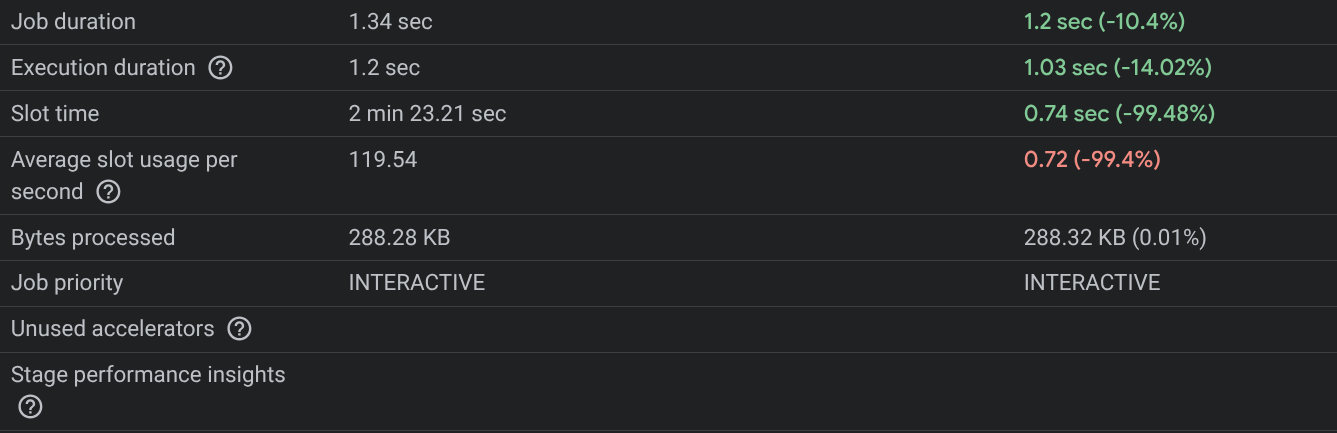

In [63]:
###Step5. Metadata Compaction 하기

job_code=f'''
import pyspark
from pyspark.sql import SparkSession
import random
from datetime import datetime, timedelta

spark = SparkSession.builder \\
    .appName("Iceberg-Small-File-Compactor") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.type', 'rest') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.warehouse', "{warehouse}") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.header.x-goog-user-project', "{project_id}") \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .config('spark.sql.catalog.{step2_bqcf_catalog_name}.rest-metrics-reporting-enabled', 'false') \\
    .config('spark.sql.defaultCatalog', "{step2_bqcf_catalog_name}") \\
    .getOrCreate()

try:
    spark.sql("USE `{step2_bqcf_catalog_name}`")
    spark.sql("USE `ifc_db`")

    print("🏃 JSON 정리 작업 시작...")

    spark.sql("""
              ALTER TABLE small_file_table SET TBLPROPERTIES (
                'write.metadata.delete-after-commit.enabled'='true',
                'write.metadata.previous-versions-max'='1'
                )
            """)

    #위에 세운 규칙 작동을 위한 트리거용
    spark.sql("""
        INSERT INTO small_file_table VALUES
        (99999, 'Cleanup', 'Trigger Commit', current_timestamp())
    """)

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''

with open("file_compaction_03.py", "w") as f:
    f.write(job_code)

print("✅ file_compaction_03.py 생성 완료")



✅ file_compaction_03.py 생성 완료


In [64]:
###Step6. Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "jobs", "submit", "pyspark", "file_compaction_03.py",
       "--cluster", cluster_name,
       "--region", region]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Job [3ec1f91be9d04a5291f26c4801801b61] submitted.
Waiting for job output...
26/03/11 03:57:37 INFO SparkEnv: Registering MapOutputTracker
26/03/11 03:57:37 INFO SparkEnv: Registering BlockManagerMaster
26/03/11 03:57:37 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/11 03:57:37 INFO SparkEnv: Registering OutputCommitCoordinator
26/03/11 03:57:38 INFO MetricsConfig: Loaded properties from hadoop-metrics2.properties
26/03/11 03:57:38 INFO MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
26/03/11 03:57:38 INFO MetricsSystemImpl: google-hadoop-file-system metrics system started
26/03/11 03:57:38 INFO DataprocSparkPlugin: Registered 189 driver metrics
26/03/11 03:57:39 INFO DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at iceberg-dataproc-497822924350-m.asia-northeast3-b.c.icebergnotbookreview.internal./10.178.0.9:8032
26/03/11 03:57:39 INFO AHSProxy: Connecting to Application History server at iceberg-dataproc-497822924350-

👀 Let's CHECK!    

GCS에서 Metadata가 어떻게 저장되었는지 분석해보세요. 위 실습 예제는 과거 5개와 현재 1개의 Metadata만 남겨놓고 정리한 예제입니다.

###4. Dataproc Lightning Engine Performance(Standard vs Premium)

#### Objective
*   Serverless Dataproc + Lightning engine 성능을 봅니다.


#### Preface
Dataproc에서 Spark 성능은 압도적입니다. 특히, Lightning engine을 적용하면 기존 대비 3~4배는 빠른 컴퓨팅 성능을 얻을 수 있습니다. 타사 대비해도 높은 성능을 자랑합니다. 해당 엔진은 빅데이터를 대상으로 복잡한 연산을 필요 할수록 더 큰 성능을 얻습니다. 검증을 위해 Iceberg 테이블로 구성해 한 번 보겠습니다.  
주의 할 점은, 성능 검증을 위해서 무거운 작업을 진행합니다. 높은 비용이 청구될 수 있으므로 해당 실습의 결과를 참고만 하거나 크기를 줄여서 실습해도 충분히 인사이트를 얻을 수 있을 것으로 보입니다.

In [65]:
###필요한 변수 선언
warehouse = f"gs://{catalog_name}"

In [66]:
###Step1. 데이터 쿼리(Lightning Engine Off)
###시나리오--
###2024년 1월 데이터와 2023년 1월 데이터를 title과 wiki 컬럼으로 Join 하여
###전년 대비 동일 월에 조회수 변동폭이 가장 큰 문서를 찾아냅니다.
###약 150~200GB 스캔함에 따라 비용과 컴퓨팅 시간이 크므로 실습에 참고하세요. 줄인다면, datehour 범위를 줄입니다.

job_code=f'''
import sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, abs as spark_abs

spark = SparkSession.builder \\
    .appName("Dataproc Lightning Performance Test") \\
    .config('spark.sql.catalog.{catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
    .config('spark.sql.catalog.{catalog_name}.type', 'rest') \\
    .config('spark.sql.catalog.{catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
    .config('spark.sql.catalog.{catalog_name}.warehouse', '{warehouse}') \\
    .config('spark.sql.catalog.{catalog_name}.header.x-goog-user-project', '{project_id}') \\
    .config('spark.sql.catalog.{catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
    .config('spark.sql.catalog.{catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .config('spark.sql.catalog.{catalog_name}.rest-metrics-reporting-enabled', 'false') \\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog') \\
    .config('spark.sql.defaultCatalog', "{catalog_name}") \\
    .getOrCreate()

try:

    print("🏃 Catalog 지정...")
    spark.sql("USE `{catalog_name}`")

    print("🏃 Namespace 지정합니다. 없는 경우 생성합니다...")
    spark.sql("CREATE NAMESPACE IF NOT EXISTS lightning_db_off")
    spark.sql("USE lightning_db_off")

    print("🏃 공개 데이터세트 BigQuery (100GB+)로부터 Iceberg 작성...")
    df_2024 = spark.read \\
        .format("bigquery") \\
        .option("table", "bigquery-public-data:wikipedia.pageviews_2024") \\
        .load() \\
        .where("datehour >= '2024-01-01 00:00:00' AND datehour <= '2024-01-31 23:59:59'")


    df_2024.writeTo("wikipedia2024") \\
        .tableProperty("write.format.default", "parquet") \\
        .partitionedBy(col("wiki")) \\
        .createOrReplace()

    print("🏃 JOIN 대상 데이터 로드...")
    df_2023 = spark.read \\
        .format("bigquery") \\
        .option("table", "bigquery-public-data:wikipedia.pageviews_2023") \\
        .load() \\
        .where("datehour >= '2023-01-01 00:00:00' AND datehour <= '2023-01-31 23:59:59'")

    print("🏃 Iceberg & BigQuery JOIN + Aggregation 연산 수행...")
    ice_2024 = spark.table("wikipedia2024")

    # wiki 프로젝트별 페이지 뷰 통계를 뽑습니다.
    result_df = ice_2024.alias("curr").join(
            df_2023.alias("prev"),
            (col("curr.title") == col("prev.title")) & (col("curr.wiki") == col("prev.wiki"))
        ) \\
        .select(
            col("curr.title"),
            col("curr.wiki"),
            col("curr.views").alias("views_2024"),
            col("prev.views").alias("views_2023")
        ) \\
        .groupBy("curr.title", "curr.wiki") \\
        .agg(
            sum("views_2024").alias("total_2024"),
            sum("views_2023").alias("total_2023")
        ) \\
        .withColumn("diff", spark_abs(col("total_2024") - col("total_2023"))) \\
        .orderBy(col("diff").desc())

    #상위 20개 출력
    result_df.show(20)

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''

with open("dataproc_lightning_01.py", "w") as f:
    f.write(job_code)

print("✅ dataproc_lightning_02.py 생성 완료")

✅ dataproc_lightning_02.py 생성 완료


In [67]:
###Step2. Lightning Engine OFF일 때의 Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "batches", "submit", "pyspark", "dataproc_lightning_01.py",
       "--batch", "lightning-test-01",
       "--region", region,
       "--deps-bucket", f"gs://{catalog_name}",
       "--version", "2.3",
       "--properties", "spark.jars.packages=org.apache.iceberg:iceberg-spark-runtime-3.5_2.13:1.5.0"]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Batch [lightning-test-01] submitted.
Using the default container image
Waiting for container log creation
PYSPARK_PYTHON=/opt/dataproc/conda/bin/python
Generating /home/spark/.pip/pip.conf
Configuring index-url as 'https://asia-python.pkg.dev/artifact-registry-python-cache/virtual-python/simple/'
JAVA_HOME=/usr/lib/jvm/temurin-17-jdk-amd64
SPARK_EXTRA_CLASSPATH=
:: loading settings :: file = /etc/spark/conf/ivysettings.xml
:: loading settings :: url = jar:file:/usr/lib/spark/jars/ivy-2.5.2.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/spark/.ivy2/cache
The jars for the packages stored in: /home/spark/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.5_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-a5213dce-f7f5-4026-850d-49610e4f0433;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.5_2.13;1.5.0 in gcs-maven-mirror
downloading https://maven-central-asia.storage-downl

In [ ]:
###Step3. 데이터 쿼리(Lightning Engine On)
###시나리오--
###2024년 1월 데이터와 2023년 1월 데이터를 title과 wiki 컬럼으로 Join 하여
###전년 대비 동일 월에 조회수 변동폭이 가장 큰 문서를 찾아냅니다.
###약 150~200GB 스캔함에 따라 비용과 컴퓨팅 시간이 크므로 실습에 참고하세요. 줄인다면, datehour 범위를 줄입니다.

job_code=f'''
import sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, abs as spark_abs

spark = SparkSession.builder \\
    .appName("Dataproc Lightning Performance Test") \\
    .config('spark.sql.catalog.{catalog_name}', 'org.apache.iceberg.spark.SparkCatalog') \\
    .config('spark.sql.catalog.{catalog_name}.type', 'rest') \\
    .config('spark.sql.catalog.{catalog_name}.uri', 'https://biglake.googleapis.com/iceberg/v1/restcatalog') \\
    .config('spark.sql.catalog.{catalog_name}.warehouse', '{warehouse}') \\
    .config('spark.sql.catalog.{catalog_name}.header.x-goog-user-project', '{project_id}') \\
    .config('spark.sql.catalog.{catalog_name}.rest.auth.type', 'org.apache.iceberg.gcp.auth.GoogleAuthManager') \\
    .config('spark.sql.catalog.{catalog_name}.io-impl', 'org.apache.iceberg.gcp.gcs.GCSFileIO') \\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions') \\
    .config('spark.sql.catalog.{catalog_name}.rest-metrics-reporting-enabled', 'false') \\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog') \\
    .config('spark.sql.defaultCatalog', "{catalog_name}") \\
    .getOrCreate()

try:

    print("🏃 Catalog 지정...")
    spark.sql("USE `{catalog_name}`")

    print("🏃 Namespace 지정합니다. 없는 경우 생성합니다...")
    spark.sql("CREATE NAMESPACE IF NOT EXISTS lightning_db_on")
    spark.sql("USE lightning_db_on")

    print("🏃 공개 데이터세트 BigQuery (100GB+)로부터 Iceberg 작성...")
    df_2024 = spark.read \\
        .format("bigquery") \\
        .option("table", "bigquery-public-data:wikipedia.pageviews_2024") \\
        .load() \\
        .where("datehour >= '2024-01-01 00:00:00' AND datehour <= '2024-01-31 23:59:59'")


    df_2024.writeTo("wikipedia2024") \\
        .tableProperty("write.format.default", "parquet") \\
        .partitionedBy(col("wiki")) \\
        .createOrReplace()

    print("🏃 JOIN 대상 데이터 로드...")
    df_2023 = spark.read \\
        .format("bigquery") \\
        .option("table", "bigquery-public-data:wikipedia.pageviews_2023") \\
        .load() \\
        .where("datehour >= '2023-01-01 00:00:00' AND datehour <= '2023-01-31 23:59:59'")

    print("🏃 Iceberg & BigQuery JOIN + Aggregation 연산 수행...")
    ice_2024 = spark.table("wikipedia2024")

    # wiki 프로젝트별 페이지 뷰 통계를 뽑습니다.
    result_df = ice_2024.alias("curr").join(
            df_2023.alias("prev"),
            (col("curr.title") == col("prev.title")) & (col("curr.wiki") == col("prev.wiki"))
        ) \\
        .select(
            col("curr.title"),
            col("curr.wiki"),
            col("curr.views").alias("views_2024"),
            col("prev.views").alias("views_2023")
        ) \\
        .groupBy("curr.title", "curr.wiki") \\
        .agg(
            sum("views_2024").alias("total_2024"),
            sum("views_2023").alias("total_2023")
        ) \\
        .withColumn("diff", spark_abs(col("total_2024") - col("total_2023"))) \\
        .orderBy(col("diff").desc())

    #상위 20개 출력
    result_df.show(20)

except Exception as e:
    print(f'⚠️ 에러 발생: {{e}}')

spark.stop()
'''

with open("dataproc_lightning_02.py", "w") as f:
    f.write(job_code)

print("✅ dataproc_lightning_01.py 생성 완료")

✅ dataproc_lightning_01.py 생성 완료


In [ ]:
###Step4. Lightning Engine ON일 때의 Job 제출

print(f"✍️ Job 제출...")

cmd = ["gcloud", "dataproc", "batches", "submit", "pyspark", "dataproc_lightning_02.py",
       "--batch", "lightning-test-02",
       "--region", region,
       "--deps-bucket", f"gs://{catalog_name}",
       "--version", "2.3",
       "--properties", "dataproc.tier=premium,spark.jars.packages=org.apache.iceberg:iceberg-spark-runtime-3.5_2.13:1.5.0"]

result = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

for line in result.stdout:
  print(line, end='')

result.wait()

if result.returncode == 0:
  print("🏁 Job 동작 완료")
else:
  print(f"⚠️ 에러 로그: \n{result.returncode}")
  print("❌ Job 동작 실패")

✍️ Job 제출...
Batch [lightning-test-00] submitted.
Using the default container image
Waiting for container log creation
PYSPARK_PYTHON=/opt/dataproc/conda/bin/python
Generating /home/spark/.pip/pip.conf
Configuring index-url as 'https://asia-python.pkg.dev/artifact-registry-python-cache/virtual-python/simple/'
JAVA_HOME=/usr/lib/jvm/temurin-17-jdk-amd64
SPARK_EXTRA_CLASSPATH=
:: loading settings :: file = /etc/spark/conf/ivysettings.xml
:: loading settings :: url = jar:file:/usr/lib/spark/jars/ivy-2.5.2.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/spark/.ivy2/cache
The jars for the packages stored in: /home/spark/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.5_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-a3b27ded-2d8f-4ad7-a51e-bf03d6cc085e;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.5_2.13;1.5.0 in gcs-maven-mirror
downloading https://maven-central-asia.storage-downl

👀 Let's CHECK!    

Dataproc > Bathces > 제출한 Batch ID > Details 통해 작업시간을 확인해보세요. 그리고, 다양한 지표를 살펴보세요!

결과를 살펴보겠습니다.  
⚠️ 해당 실습과는 별개의 데이터로 작업한 결과입니다.  

50GB일 때

Lightning Engine OFF
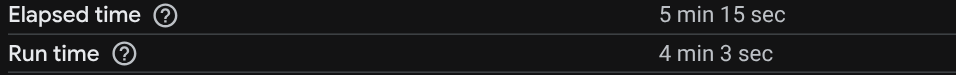

Lightning Engine ON
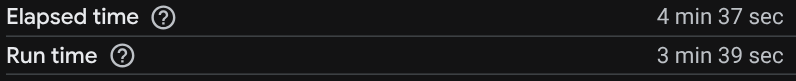

500GB일 때

Lightning Engine OFF
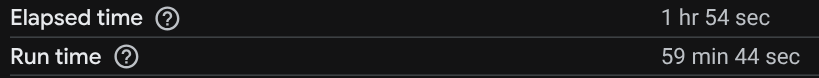

Lightning Engine ON
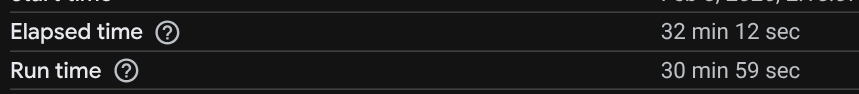

👀 데이터의 크기가 커질 수록, 연산이 복잡해질 수록 Lightning Engine의 Performance는 커집니다. Dataproc가 주는 Manage point의 편리함과 성능을 누려보세요.

🏁 FINISH LINE!  

GCP환경에서 Iceberg를 활용해 다양한 실습을 해봤습니다. 마지막은, Dataproc의 성능을 검증하기 까지 했습니다. 이 긴 여정을 거쳐온 모든 분들께 박수를 보내며 마칩니다. 👏👏👏  